## 1. Understanding the Black-Scholes Model

During my course *Stochastic Calculus and its Applications*, I was introduced to the Black-Scholes model. This model provides a framework for pricing European options by using theory of stochastic processes.

The central idea behind the model is that if the underlying asset follows a stochastic process and if risk can be continuously hedged away, then derivatives written on that asset must have a unique fair price. Starting with an SDE, applying these principles and solving the resulting Black-Scholes PDE yields the closed-form pricing formulas for European call and put options.

Our model begins with the assumption that the stock price evolves according to Geometric Brownian Motion (modeled by drift and diffusion; prices stay positive and evolve continuously):

$$
dS = \mu Sdt + \sigma SdW_t
$$

where:

* $S$ is the stock price,
* $\mu$ is drift,
* $\sigma$ is the volatility,
* $dW_t$ is the increment of a Brownian motion.

Here, $\mu Sdt$ corresponds to deterministic growth and $\sigma SdW_t$ corresponds to randomness.

The randomness enters through Brownian motion, which models random fluctuations in the markets. The volatility term scales the magnitude of these fluctuations. Since the stochastic term is proportional to the stock price itself, the model captures percentage price changes rather than absolute changes, which is more realistic for us.

So, the explicit solution to the stochastic differential equation is:

$$
S_t = S_0 \exp\left[\left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W_t\right]
$$

We know the value of an option depends on both the stock price and time:

$$
V = V(S,t)
$$

Since the stock price itself evolves randomly, the option price must also be stochastic. Now to determine the changes in option value over time we use Itô’s formula.

$$
dV
=

\frac{\partial V}{\partial t}dt
+
\frac{\partial V}{\partial S}dS
+
\frac{1}{2}
\frac{\partial^2 V}{\partial S^2}
(dS)^2
$$

Substituting the equation of the process:

$$
dS = \mu Sdt + \sigma SdW_t
$$

and using the identities:

$$
(dW_t)^2 = dt
$$

$$
dt^2 = 0
$$

$$
dt \cdot dW_t = 0
$$

we get:

$$
(dS)^2 = \sigma^2 S^2 dt
$$

Substituting back into Itô’s expansion:

$$
dV
=

\left(
\frac{\partial V}{\partial t}
+
\mu S \frac{\partial V}{\partial S}
+
\frac{1}{2}\sigma^2 S^2
\frac{\partial^2 V}{\partial S^2}
\right)dt
+
\sigma S
\frac{\partial V}{\partial S}
dW_t
$$

Now we still have a deterministic component and a stochastic component (driven by Brownian motion).

Our attempt with Black-Scholes is to eliminate stochasticity completely by dynamically hedging the portfolio. For this we consider the portfolio:

$$
\Pi = V - \Delta S
$$

This represents:

* a long position in one option,
* and a short position in $\Delta$ shares of the underlying stock.

The change in the portfolio value is:

$$
d\Pi = dV - \Delta dS
$$

Substituting the expressions for $dV$ and $dS$:

$$
d\Pi
=

\left(
\frac{\partial V}{\partial t}
+
\mu S \frac{\partial V}{\partial S}
+
\frac{1}{2}\sigma^2 S^2
\frac{\partial^2 V}{\partial S^2}
\right)dt
+
\sigma S
\frac{\partial V}{\partial S} dW_t
- 
\Delta
\left(
\mu Sdt + \sigma SdW_t
\right)
$$

Choosing

$$
\Delta = \frac{\partial V}{\partial S}
$$

so that we can cancel the stochastic term



The portfolio is now locally riskless:

$$
d\Pi =
\left(
\frac{\partial V}{\partial t}
+
\frac{1}{2}\sigma^2 S^2
\frac{\partial^2 V}{\partial S^2}
\right)dt
$$

At this point, we inntroduce the principle of no arbitrage. In an arbitrage-free market, a riskless portfolio must earn the risk-free rate of return $r$. Otherwise, investors could generate profits without taking risk.

Therefore:

$$
d\Pi = r\Pi dt
$$

Since

$$
\Pi = V - S\frac{\partial V}{\partial S}
$$

we get

$$
\left(
\frac{\partial V}{\partial t}
+
\frac{1}{2}\sigma^2 S^2
\frac{\partial^2 V}{\partial S^2}
\right)
=

r
\left(
V - S\frac{\partial V}{\partial S}
\right)
$$

Rearranging terms finally yields the Black-Scholes PDE:

$$
\frac{\partial V}{\partial t}
+
\frac{1}{2}\sigma^2 S^2
\frac{\partial^2 V}{\partial S^2}
+
rS\frac{\partial V}{\partial S}
-  rV
= 
0
$$

This PDE must be satisfied by any derivative whose underlying asset follows Geometric Brownian Motion under the Black-Scholes assumptions.

In order to determine the unique solution we need boundary conditions. 

So for a European call option:

$$
V(S,T)=\max(S-K,0)
$$

where:

* $K$ is the strike price,
* $T$ is the time of maturity.

So this is the payoff received at expiration.

The PDE is then transformed into the classical heat equation using:

* logarithmic transformations,
* time reversal,
* and variable substitutions.

Solving the transformed equation produces the Black-Scholes closed-form pricing formula for a European call option:

$$
C = S_0N(d_1) - Ke^{-rT}N(d_2)
$$

where:

$$
d_1 =
\frac{
\ln(S_0/K)
+
\left(r+\frac{1}{2}\sigma^2\right)T
}{
\sigma\sqrt{T}
}
$$

and

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

Here $N(d)$ denotes the cumulative distribution function of the standard normal distribution and $S_0$ is the current stock price.

The first term

$$
S_0N(d_1)
$$

can be understood as the probability-adjusted expected value of owning the stock under the risk-neutral measure.

The second term

$$
Ke^{-rT}N(d_2)
$$

represents the discounted expected strike payment weighted by the risk-neutral exercise probability.

Using put-call parity, the corresponding European put price is:

$$
P = Ke^{-rT}N(-d_2) - S_0N(-d_1)
$$

Note that in this derivation the drift term $\mu$ disappears completely from the final PDE and pricing formula. This implies that derivative pricing does not depend on investors’ subjective expectations about future returns. Instead, pricing depends only on:

* volatility,
* replication,
* hedging,
* and no-arbitrage conditions.

This idea leads directly to risk-neutral pricing and modern martingale theory.

The Black-Scholes framework fundamentally states that if a derivative’s risk can be perfectly replicated and continuously hedged using traded assets, then its price is uniquely determined by no-arbitrage.

But the model is based on various assumptions:

* constant volatility,
* constant interest rates,
* continuous trading,
* frictionless markets,
* no transaction costs,
* no jumps in asset prices,
* and lognormally distributed stock prices.

Real financial markets violate many of these assumptions. In practice, markets exhibit:

* volatility smiles and skews,
* jumps and crashes,
* liquidity constraints,
* stochastic volatility,
* and heavy-tailed return distributions.

These limitations motivate more advanced models such as:

* Heston stochastic volatility models,
* jump diffusion models,
* local volatility models,
* SABR models,
* and rough volatility frameworks.

But still, the Black-Scholes model is quite important for us because it introduces to the fundamentals of derivative pricing, dynamic hedging and risk-neutral valuation.


In [13]:
# installing basic packages


import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from scipy.optimize import brentq   # For implied volatility inversion
import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings('ignore')
np.random.seed(42)           # For reproducibility
torch.manual_seed(42)

# Nice plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.size':        11,
})
print("All imports OK.")


All imports OK.


Now I introduce the first basic code of the derivation we just did. 
- S     : current stock price
- K     : strike price
- T     : time to expiry in years  
- r     : annual risk-free rate 
- sigma : annual volatility of log-returns

As we all know, these are two kinds of options we can have pricing for. The BS Model put-call parity formula gives the following equations:

$ C = SN(d1) - K\exp(-rT)N(d2), \quad \quad \quad P = K\exp(-rT)N(-d2) - SN(-d1) $

In [14]:
# Applying Black Scholes

def bs_d1_d2(S, K, T, r, sigma): # for computing d1 and d2

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


def black_scholes(S, K, T, r, sigma, option_type='call'): # using BS clsoed form formula

    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    
    if option_type == 'call':
        price = S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    return price


# we first use at the money parameters 
S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20

call = black_scholes(S, K, T, r, sigma, 'call')
put  = black_scholes(S, K, T, r, sigma, 'put')

# put-call parity
parity = call - put
theoretical_parity = S - K * np.exp(-r * T)

print("BLACK SCHOLES PRICING OF CALL AND PUT OPTIONS FOR GIVEN PARAMETERS")
print(f"  Parameters:   S={S}, K={K}, T={T}y, r={r:.0%}, σ={sigma:.0%}")
print(f"  Call price:   £{call:.4f}")
print(f"  Put price:    £{put:.4f}")
print()
print("Put Call Parity verification")
print(f"  C - P               = {parity:.6f}")
print(f"  S - K·exp(-rT)      = {theoretical_parity:.6f}")
print(f"  Parity holds:         {np.isclose(parity, theoretical_parity)}")
print()
print("Interpretation: paying £{:.2f} for this call gives you the right".format(call))
print("to buy a £100 stock for £100 in one year. The market's 20% vol")
print("estimate means the stock has a decent chance of ending above £100.")


BLACK SCHOLES PRICING OF CALL AND PUT OPTIONS FOR GIVEN PARAMETERS
  Parameters:   S=100, K=100, T=1.0y, r=5%, σ=20%
  Call price:   £10.4506
  Put price:    £5.5735

Put Call Parity verification
  C - P               = 4.877058
  S - K·exp(-rT)      = 4.877058
  Parity holds:         True

Interpretation: paying £10.45 for this call gives you the right
to buy a £100 stock for £100 in one year. The market's 20% vol
estimate means the stock has a decent chance of ending above £100.


###  How the price varies with each input

Now let us see how changing spot prices influence the price of options. This concept is represented by $\Delta$
Let's try visualise how the call price moves with each input. The idea is to vary one parameter while keeping all others fixed.


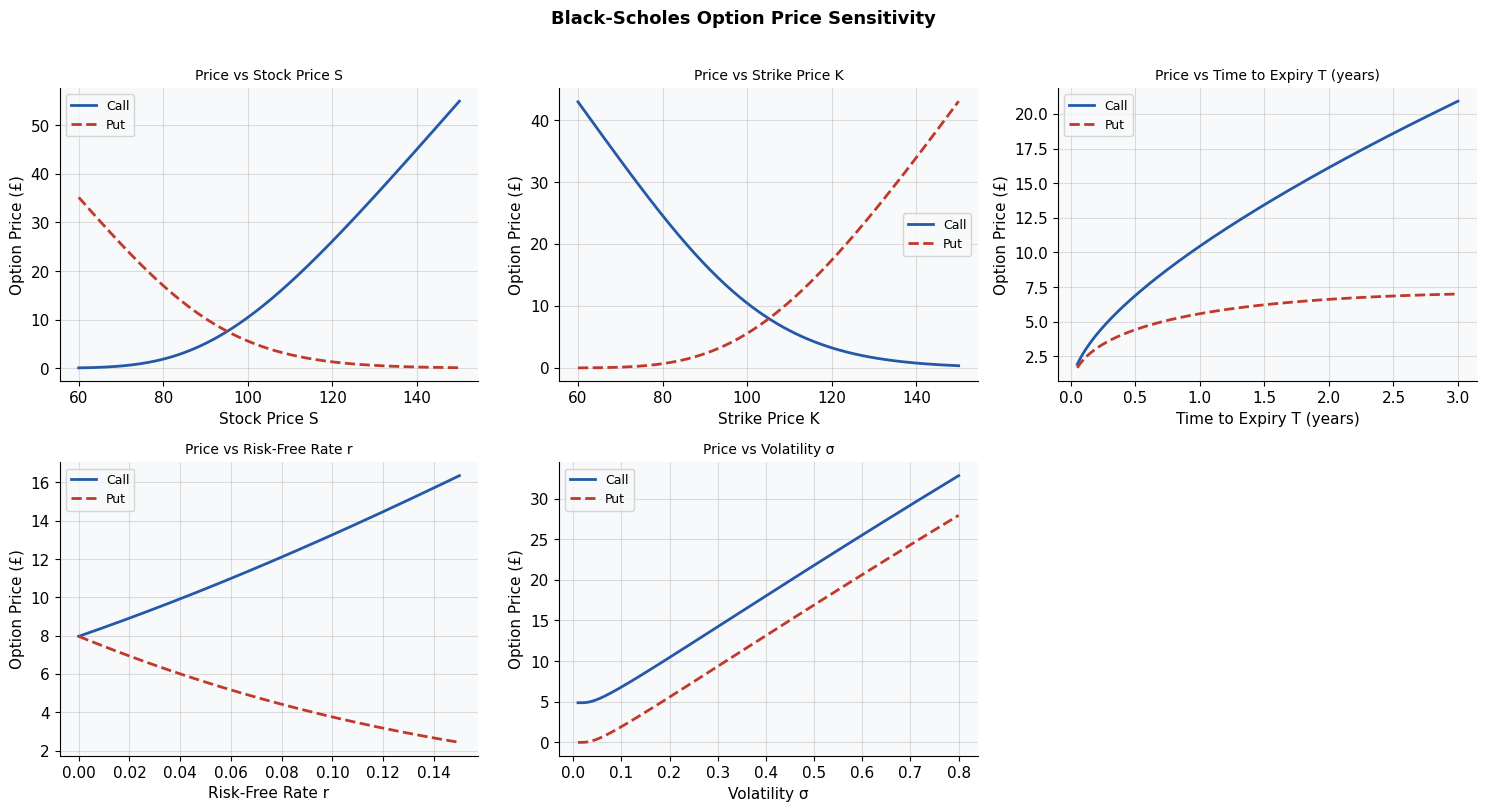

Notice: call price is monotone increasing in S, σ, T, r. Put is the opposite in S and r.


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Base parameters
base = dict(S=100, K=100, T=1.0, r=0.05, sigma=0.20)

params = [
    ('S',     np.linspace(60, 150, 300),  'Stock Price S'),
    ('K',     np.linspace(60, 150, 300),  'Strike Price K'),
    ('T',     np.linspace(0.05, 3, 300),  'Time to Expiry T (years)'),
    ('r',     np.linspace(0, 0.15, 300),  'Risk-Free Rate r'),
    ('sigma', np.linspace(0.01, 0.80, 300), 'Volatility σ'),
]

for ax, (param, vals, xlabel) in zip(axes, params):
    call_prices = []
    put_prices  = []
    for v in vals:
        p = {**base, param: v}      # copy base params, swap one
        call_prices.append(black_scholes(**p, option_type='call'))
        put_prices.append(black_scholes(**p,  option_type='put'))
    
    ax.plot(vals, call_prices, label='Call', color='#2459A8', lw=2)
    ax.plot(vals, put_prices,  label='Put',  color='#C0392B', lw=2, ls='--')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Option Price (£)')
    ax.legend(fontsize=9)
    ax.set_title(f'Price vs {xlabel}', fontsize=10)

axes[-1].axis('off')   # hide the 6th panel
plt.suptitle('Black-Scholes Option Price Sensitivity', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bs_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Notice: call price is monotone increasing in S, σ, T, r. Put is the opposite in S and r.")


## Understanding the Black-Scholes Sensitivity Graphs

1. The graph titled **Price vs Stock Price $S$** shows how option values behave as the underlying stock price changes : 
As the stock price increases the call option price increases while the put option price decreases. 
This happens because a call option gives the holder the right to buy the stock at strike price $K$. If the stock price rises significantly above the strike price, the option becomes more valuable since buying at $K$ and selling at market price becomes profitable. On the other hand, a put option gives the right to sell at strike price $K$. As the stock price rises, this right becomes less valuable because selling at $K$ is no longer advantageous when the market price is already high. In essence calls benefit from upward price movement and puts benefit from downward price movement.

2. The graph titled **Price vs Strike Price $K$** studies how changing the strike price affects option value: As strike price increases call option prices decrease anf put option prices increase. This can be understood directly from the payoff functions: 
$$\text{For a call: Payoff=}
\max(S-K,0)
$$
$\quad \quad$ A larger strike price means the holder must pay more to exercise the option, making the option less attractive.

$$ \text{For a put: Payoff=}
\max(K-S,0)
$$

$\quad \quad$ A larger strike price increases the value of the right to sell at that higher price. This introduces us to the idea of an option being "in the money", "at-the-money" or "out of the money".

3. The graph titled **Price vs Time to Expiry $T$** demonstrates the effect of time on option value: As time to maturity increases both call and put prices generally increase. This is because more time means more uncertainty, more scope future price movement and therefore a greater probability of favorable outcomes. For calls more time increases the probability that the stock rises above the strike. For puts  more time increases the probability that the stock falls below the strike. As expiration approaches uncertainty decreases, "time value" decays and option prices converge toward intrinsic value.This phenomenon is measured by the Greek letter $
\Theta $ aka Theta or time decay.

4. The graph titled **Price vs Risk-Free Rate $r$** illustrates how interest rates influence option prices: As the risk-free rate increases call prices increase but put prices decrease. The Black-Scholes call price contains the discounted strike term:

$$
Ke^{-rT}
$$

$\quad \quad$ As interest rates rise the present value of the strike payment decreases, making the call option more valuable. Intuitively owning a call delays payment of the strike price until maturity and higher rates make delayed payment more attractive.

5. The graph titled **Price vs Volatility $\sigma$** is nice: As volatility increases both call and put prices increase. This happens because options love uncertainty. An option holder has limited downside but potentially large upside. Greater volatility increases the probability of extreme favorable outcomes while losses remain bounded by the option premium. This sensitivity is measured by the greek letter $ \nu $ called Vega.


Note that option pricing is nonlinear. Unlike stocks option prices do not move linearly because sensitivities themselves change dynamically. This is why we need mathematical models in the first place


## 2. Introducing The Greeks

The "Greeks" measure how the option price changes with each input, i.e, their sensitivity. In order to hedge posiitons, these are important. 

| Greek | Symbol | What it measures |
|---|---|---|
| Delta | Δ | dC/dS — price change per £1 move in spot |
| Gamma | Γ | d²C/dS² — rate of change of Delta | 
| Vega | ν | dC/dσ — price change per 1% volatility move | 
| Theta | Θ | dC/dT — price decay per day | 
| Rho | ρ | dC/dr — price change per 1% rate move | 

The BS formula gives us direct equations for these greek letters
$$\Delta = N(d1) $$
$$\Gamma = φ(d1) / (S·σ·√T) \text{ where φ is the standard normal PDF} $$
$$\nu  = S·φ(d1)·√T $$
$$\Theta = -[S·φ(d1)·σ/(2√T)] - r·K·e^{-rT}·N(d2) $$
$$\rho   = K·T·e^{-rT}·N(d2) $$


In [16]:
# calculating the exact greeks of the BS closed form formula 
def bs_greeks(S, K, T, r, sigma, option_type='call'):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma) #usinng last code
    pdf_d1 = si.norm.pdf(d1)   # standard normal density at d1
    
    if option_type == 'call':
        delta = si.norm.cdf(d1)
        rho   = K * T * np.exp(-r * T) * si.norm.cdf(d2)
        theta = (-(S * pdf_d1 * sigma) / (2 * np.sqrt(T))
                 - r * K * np.exp(-r * T) * si.norm.cdf(d2)) / 365  # per day
    else:
        delta = si.norm.cdf(d1) - 1        # call delta - 1
        rho   = -K * T * np.exp(-r * T) * si.norm.cdf(-d2)
        theta = (-(S * pdf_d1 * sigma) / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * si.norm.cdf(-d2)) / 365  # per day
    
    # Gamma and Vega are the same for calls and puts because of the symmetry of put-call parity
    gamma = pdf_d1 / (S * sigma * np.sqrt(T))
    vega  = S * pdf_d1 * np.sqrt(T) / 100   # per 1% vol move

    return {'delta': delta, 'gamma': gamma, 'vega': vega,
            'theta': theta, 'rho': rho}


g_call = bs_greeks(S, K, T, r, sigma, 'call')
g_put  = bs_greeks(S, K, T, r, sigma, 'put')

print("Greeks at S=K=100, T=1y, r=5%, σ=20%")
print(f"{'Greek':<10}  {'Call':>12}  {'Put':>12}  {'Intuition'}")
print("-" * 70)
print(f"{'Delta':<10}  {g_call['delta']:>12.4f}  {g_put['delta']:>12.4f}  "
      "  £ change in option per £1 in stock")
print(f"{'Gamma':<10}  {g_call['gamma']:>12.4f}  {g_put['gamma']:>12.4f}  "
      "  ΔDelta per £1 in stock")
print(f"{'Vega':<10}  {g_call['vega']:>12.4f}  {g_put['vega']:>12.4f}  "
      "  £ change per 1% rise in volatility")
print(f"{'Theta':<10}  {g_call['theta']:>12.4f}  {g_put['theta']:>12.4f}  "
      "  £ decay per calendar day")
print(f"{'Rho':<10}  {g_call['rho']:>12.4f}  {g_put['rho']:>12.4f}  "
      "  £ change per 1% rise in rates")


Greeks at S=K=100, T=1y, r=5%, σ=20%
Greek               Call           Put  Intuition
----------------------------------------------------------------------
Delta             0.6368       -0.3632    £ change in option per £1 in stock
Gamma             0.0188        0.0188    ΔDelta per £1 in stock
Vega              0.3752        0.3752    £ change per 1% rise in volatility
Theta            -0.0176       -0.0045    £ decay per calendar day
Rho              53.2325      -41.8905    £ change per 1% rise in rates


Now I study $\Delta$ and $\Gamma$ a little more in depth. I visualise their variation as a function of spot price for different times of maturity.

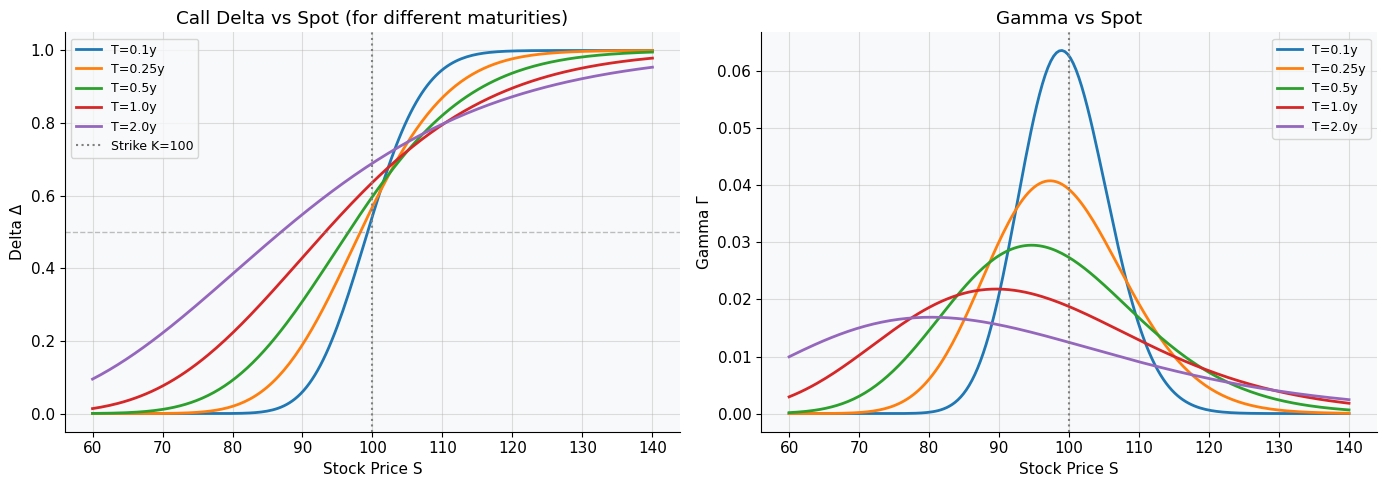

In [17]:

S_range = np.linspace(60, 140, 200)
T_values = [0.1, 0.25, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Delta as a function of spot for different maturities
ax = axes[0]
for t in T_values:
    deltas = [bs_greeks(s, 100, t, 0.05, 0.20, 'call')['delta'] for s in S_range]
    ax.plot(S_range, deltas, label=f'T={t}y', lw=2)
ax.axvline(100, color='gray', ls=':', lw=1.5, label='Strike K=100')
ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('Stock Price S')
ax.set_ylabel('Delta Δ')
ax.set_title('Call Delta vs Spot (for different maturities)')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)

# Right: Gamma across spot (same maturities)

ax = axes[1]
for t in T_values:
    gammas = [bs_greeks(s, 100, t, 0.05, 0.20, 'call')['gamma'] for s in S_range]
    ax.plot(S_range, gammas, label=f'T={t}y', lw=2)
ax.axvline(100, color='gray', ls=':', lw=1.5)
ax.set_xlabel('Stock Price S')
ax.set_ylabel('Gamma Γ')
ax.set_title('Gamma vs Spot')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('greeks.png', dpi=150, bbox_inches='tight')
plt.show()


Notice near expiry for small $T$, $\Gamma$ spikes sharply around the strike so $\Gamma$ is highest at-the-money and concentrated near expiry, which is why expiry becomes crucial. 

## 3. Monte Carlo Pricing

We know that European options Black Scholes model has a closed form solution. However, some real world options have no closed form. So we return to Monte Carlo which uses many random simulations for future asset path and average option payoffs to estimate the option price. Mathematicaally, under risk-neutral dynamics, the stock follows:
$$S_T = S_0 \exp\left[(r - \tfrac{1}{2}\sigma^2)T + \sigma W_T\right]$$
where $W_T \sim N(0, T)$.

The option price is:
$$C = e^{-rT}\,\mathbb{E}^Q[\max(S_T - K,\, 0)]$$

So we estimate this expectation by averaging the payoff over many simulated terminal prices.

Our idea exploits the fact the under BS Model, $S_T$ is log-normally distributed:
        $$ S_T = S * exp( (r - σ²/2)*T + σ*√T*Z )   \quad \text{where} \quad  Z \sim N(0,1) $$
we take n number of paths 

We use the concept of antithetic variates for variance reduction: 

If we draw $Z \sim N(0,1)$, we can also use $-Z$ (a valid draw from the same distribution). For each path using $Z$, we get a mirrored path using $-Z$. The average of the two payoffs has lower variance than either alone because when one is high, the other tends to be low. This halves the effective standard error (or double n) at no extra cost.

In [18]:
# we only use the terminal-value and not the full path
# we do this for European options, which is fast and exact so easier to verify

def mc_european(S, K, T, r, sigma, option_type='call', n_paths=100_000,
                antithetic=True, seed=42):

    rng = np.random.default_rng(seed)
    
    # Draw standard normals by using Z and -Z as paired paths
    if antithetic:
        half = n_paths // 2
        Z = rng.standard_normal(half)
        Z = np.concatenate([Z, -Z])     
    else:
        Z = rng.standard_normal(n_paths)
    
    # simulating the exact terminal stock price 
    S_T = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # Compute payoff and discount to present value
    if option_type == 'call':
        payoffs = np.maximum(S_T - K, 0)
    else:
        payoffs = np.maximum(K - S_T, 0)
    
    discounted = np.exp(-r * T) * payoffs
    
    price = discounted.mean()
    se    = discounted.std() / np.sqrt(n_paths)    # standard error of the mean
    ci_lo = price - 1.96 * se                      # 95% confidence interval
    ci_hi = price + 1.96 * se
    
    return {'price': price, 'se': se, 'ci': (ci_lo, ci_hi)}


# MONTE CARLO VS CLOSED FORM BLACK SCHOLES 
print(" MONTE CARLO VS CLOSED FORM BLACK SCHOLES ")
print(f"{'Paths':>10}  {'MC Price':>10}  {'BS Price':>10}  {'Abs Error':>12}  {'95% CI width':>14}")
print("-" * 65)

bs_exact = black_scholes(S, K, T, r, sigma, 'call')

for n in [1_000, 10_000, 100_000, 1_000_000]:
    res = mc_european(S, K, T, r, sigma, 'call', n_paths=n, antithetic=True)
    err = abs(res['price'] - bs_exact)
    ci_w = res['ci'][1] - res['ci'][0]
    print(f"{n:>10,}  {res['price']:>10.5f}  {bs_exact:>10.5f}  "
          f"{err:>12.6f}  {ci_w:>14.6f}")

print()


 MONTE CARLO VS CLOSED FORM BLACK SCHOLES 
     Paths    MC Price    BS Price     Abs Error    95% CI width
-----------------------------------------------------------------
     1,000    10.00040    10.45058      0.450186        1.742503
    10,000    10.41005    10.45058      0.040532        0.578291
   100,000    10.46731    10.45058      0.016731        0.183146
 1,000,000    10.45654    10.45058      0.005952        0.057767



Note : error shrinks as √(1/n), 100× more paths → 10× smaller error

We worked only at terminal value, now let us visualise the simulated paths of the underlying Geometric BM. The SDE is:  
$$ dS = r·S·dt + σ·S·dW $$
Euler step:  $ S_{t+dt} = S_t · exp[(r - σ²/2)dt + σ·√dt·Z_t] $
    
This is actually the exact discretisation for GBM (no discretisation error), because GBM has a known closed-form solution.

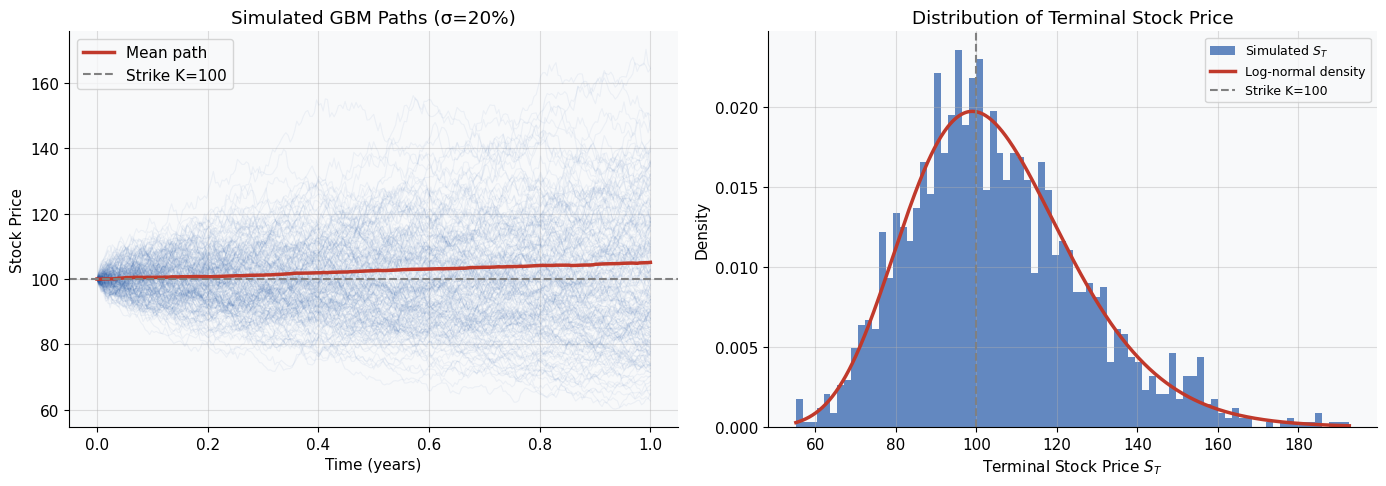

In [19]:
def simulate_gbm_paths(S0, T, r, sigma, steps, n_paths, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / steps
    
    #matrix dimension (steps+1, n_paths) so each column is one simulated path
    paths = np.zeros((steps + 1, n_paths))
    paths[0] = S0
    
    for t in range(1, steps + 1):
        Z = rng.standard_normal(n_paths)
        paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma**2) * dt
                                        + sigma * np.sqrt(dt) * Z)
    return paths


paths = simulate_gbm_paths(S0=100, T=1.0, r=0.05, sigma=0.20,
                            steps=252, n_paths=2000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax = axes[0]
#200 paths and mean path
t_grid = np.linspace(0, 1, 253)
ax.plot(t_grid, paths[:, :200], alpha=0.06, color='#2459A8', lw=0.8)
ax.plot(t_grid, paths.mean(axis=1), color='#C0392B', lw=2.5, label='Mean path')
ax.axhline(100, color='gray', ls='--', lw=1.5, label='Strike K=100')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Stock Price')
ax.set_title('Simulated GBM Paths (σ=20%)')
ax.legend()

# Histogram of terminal values vs log-normal density
ax = axes[1]
S_T = paths[-1]
ax.hist(S_T, bins=80, density=True, color='#2459A8', alpha=0.7,
        label='Simulated $S_T$')

x = np.linspace(S_T.min(), S_T.max(), 500)
mu_ln  = np.log(100) + (0.05 - 0.5 * 0.20**2) * 1.0
sig_ln = 0.20 * np.sqrt(1.0)
pdf = (1 / (x * sig_ln * np.sqrt(2*np.pi))) * np.exp(-0.5*((np.log(x) - mu_ln)/sig_ln)**2)
ax.plot(x, pdf, color='#C0392B', lw=2.5, label='Log-normal density')
ax.axvline(100, color='gray', ls='--', lw=1.5, label='Strike K=100')
ax.set_xlabel('Terminal Stock Price $S_T$')
ax.set_ylabel('Density')
ax.set_title('Distribution of Terminal Stock Price')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('mc_paths.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Implied Volatility & the Volatility Smile

The BS formula maps $(S, K, T, r, \sigma) \to C $(or $P$, i.e, price of an option). 


In real life, we observe the market price $C_{mkt}$ and then try to find the $\sigma$ that makes BS model match it. This $\sigma$ is called the **Implied Volatility (IV)**. So we just invert the Black-Scholes formula to recover the market implied volatility. The following code uses Brent's method which finds root without needing to calculate derivatives. It basically keeps guessing volatility until BS price matches market price


Note Black-Scholes assumes constant volatility, but implied volitilities (vols) vary by strike price and maturity. This is the reason for volatility smile.

**The Volatility Smile**: If BS were perfectly correct, Implied Volatility would be the same for every strike. In reality, when we plot IV against strike we get a smile like curve aka skew. For at the money strike price, BS gives certain volatility but a far away strike would would give a higher volatility.

#### Example
To understand this better remember that a put option payoff is max $ (K−S_T,0)$. So a put becomes more valuable when stock price falls below strike. 

Suppose stock price $S_0=100$ then strike prices $K=70$ is deep OTM, $K=90$ is slightly OTM and $K=100$ is ATM

Now imagine if the stock falls to 50. Then the deep OTM put is really valuable because its literally like an insurance against a big fall.

Black Scholes model assumes normal returns and that crashes are unlikely. However in real life crashes happen often and markets are skewed. So traders would be willing to pay more for this kind of insurance. 

Black-Scholes only has one free parameter $σ$. If market prices are high, the only way BS can explain them is by increasing volatility. So a low strike put produces higher IV. This creates the skewness we see in the graphs. This is one of the most important shortcomings of BS model that we shall try to fix soon. 

In the following code I create artificial market prices using a smile. Then I recover the smile via implied volatility inversion. Finally I try to show that constant volalility Black-Scholes cannot fully reproduce those prices.



Known σ: 0.234500
BS price at that σ: £11.749945
Recovered IV: 0.234500
Error: 2.47e-15



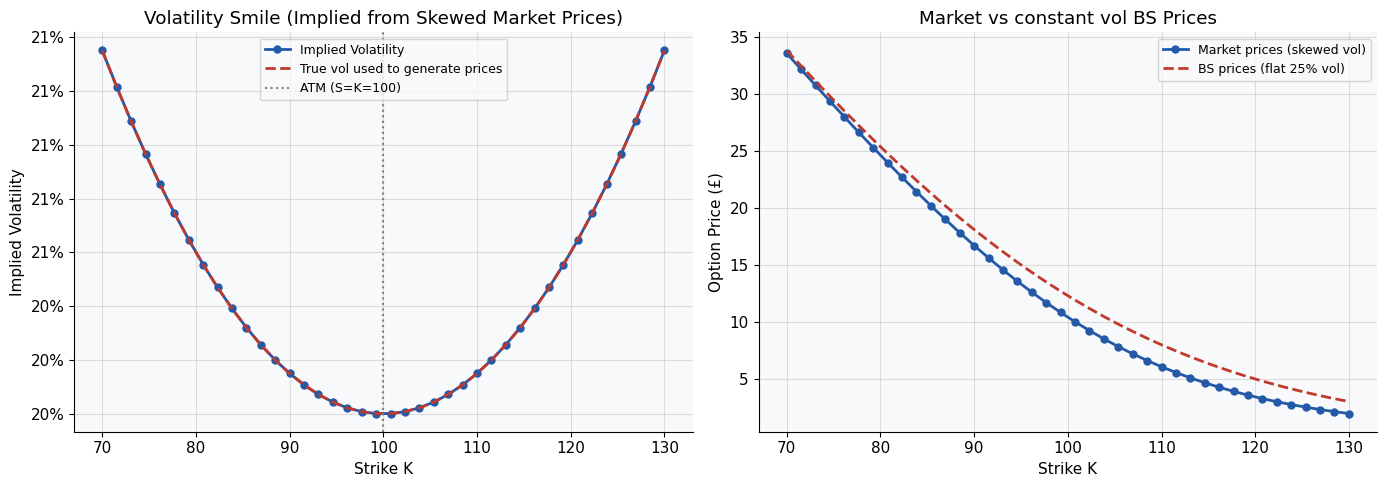

In [20]:
def implied_vol(C_market, S, K, T, r, option_type='call',
                vol_lo=1e-6, vol_hi=10.0):
    
    def objective(sigma):
        #objective =BS - market, we want this to equal zero 
        return black_scholes(S, K, T, r, sigma, option_type) - C_market
    
    try:
        # brentq requires objective to change sign on [vol_lo, vol_hi]
        iv = brentq(objective, vol_lo, vol_hi, xtol=1e-8, maxiter=200)
        return iv
    except ValueError:
        return np.nan   # no solution in range 

known_sigma = 0.2345 # used to verify later 
C_test = black_scholes(S, K, T, r, known_sigma, 'call') #directly first code
recovered_sigma = implied_vol(C_test, S, K, T, r, 'call') #uses brent's 

print(f"Known σ: {known_sigma:.6f}") 
print(f"BS price at that σ: £{C_test:.6f}")
print(f"Recovered IV: {recovered_sigma:.6f}")
print(f"Error: {abs(known_sigma - recovered_sigma):.2e}")
print()


# Simulating a volatility smile 

strikes = np.linspace(70, 130, 40)
# Quadratic skew: vol(K) = 0.20 + 0.15*(1 - K/S)^2  — symmetric smile-ish
true_vol_fn = lambda k: 0.20 + 0.15 * (1 - k / 100)**2 #creates a volatility function depending on strike because eventhough BS assumes it constant, it really isnt 

market_prices = [black_scholes(S, k, T, r, true_vol_fn(k), 'call') for k in strikes] #creating synthetic data
# we pretend the market truly follows a volatility smile and so volatility changes with strike price.

ivs = [implied_vol(c, S, k, T, r, 'call') for c, k in zip(market_prices, strikes)] #implied volatilities from those prices.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(strikes, ivs, 'o-', color='#2459A8', lw=2, ms=5, label='Implied Volatility')
ax.plot(strikes, [true_vol_fn(k) for k in strikes], '--', color='#C0392B',
        lw=2, label='True vol used to generate prices')
ax.axvline(100, color='gray', ls=':', lw=1.5, label='ATM (S=K=100)')
ax.set_xlabel('Strike K')
ax.set_ylabel('Implied Volatility')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Volatility Smile (Implied from Skewed Market Prices)')
ax.legend(fontsize=9)

# blue price generated by smile, red price generated using constant vol
ax = axes[1]
bs_flat = [black_scholes(S, k, T, r, 0.25, 'call') for k in strikes] #Black-Scholes prices assuming sigma=25%
ax.plot(strikes, market_prices, 'o-', color='#2459A8', lw=2, ms=5, label='Market prices (skewed vol)')
ax.plot(strikes, bs_flat, '--', color='#C0392B', lw=2, label='BS prices (flat 25% vol)')
ax.set_xlabel('Strike K')
ax.set_ylabel('Option Price (£)')
ax.set_title('Market vs constant vol BS Prices')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('vol_smile.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. American Options


As we know a European option can only be exercised at expiry. However, an American option can be exercised at any time up to expiry. 
At each time step we have a choice either exercise now and get the intrinsic value or continue holding and get the expected continuation value. So we exercise only if intrinsic > continuation value. This adds an optimal stopping problem on top of the pricing problem.

For a European put option, the payoff is

$$
\max(K - S_T, 0)
$$

where $K$ is the strike price and $S_T$ is the stock price at maturity.

We can find option prices using Black-Scholes closed form because the payoff only depends on the terminal stock price.

For an American put option, however, the holder may exercise at any stopping time,

$$
\tau \in [0,T]
$$

Hence, at every time step, the holder must decide between exercising the option immediately and receiving intrinsic value or continue holding the option. Mathematically, the option value satisfies:

$$
V_t
=
\max
\left(
\text{Immediate Exercise Value},
\text{Continuation Value}
\right)
$$

For an American put:

$$
V_t
=
\max
\left(
K - S_t,
\mathbb E^\mathbb Q
\left[
e^{-r\Delta t}V_{t+\Delta t}
\mid S_t
\right]
\right)
$$

where the first term represents exercising now and the second term represents continuing to hold the option.

The difficulty lies in estimating the continuation value:

$$
\mathbb E^\mathbb Q
\left[
e^{-r\Delta t}V_{t+\Delta t}
\mid S_t
\right]
$$

because this conditional expectation is generally not available analytically.

### Longstaff-Schwartz 

It is an algorithm that uses Monte Carlo simulation, backward induction and least squares regression to solve this issue.

The algorithm begins by simulating stock price paths under the risk neutral measure using Geometric Brownian Motion

$$
dS_t = rS_tdt + \sigma S_tdW_t
$$

In the following code we have used discrete-time simulation formula:

$$
S_{t+\Delta t}
=
S_t
\exp
\left[
\left(r-\frac12\sigma^2\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right]
$$

where:
- $Z \sim \mathcal N(0,1)$,
- $\Delta t = T / \text{steps}$.

The code first generates many possible future stock price paths such that ach simulated path represents one possible future trajectory of the stock price.

At maturity, the option payoff is known exactly

$$
\max(K - S_T,0)
$$

This initializes the terminal cash flows. The algorithm then works backward in time

Notes:

- The first step discounts future cash flows using $ e^{-r\Delta t}$. This converts future payoffs into present values.

- The algorithm only considers in the money paths because exercising an out-of-the-money put gives us payoff as $K-S_t<0$.

The most important part of the algorithm is estimating the continuation value.

The continuation value is:

$$
C(S_t)
=
\mathbb E^\mathbb Q
\left[
e^{-r\Delta t}V_{t+\Delta t}
\mid S_t
\right]
$$

Since this expectation is unknown, Longstaff-Schwartz approximates it using regression.

The code constructs a polynomial basis functions which assumes the continuation value can be approximated as:

$$
C(S_t)
\approx
\beta_0
+
\beta_1S_t
+
\beta_2S_t^2
$$

The regression target is the discounted future payoffs. So the regression step solves the least squares problem:

$$
\min_\beta ||X\beta - Y||^2
$$

This estimates the coefficients $\beta_0,\beta_1,\beta_2$ that best approximate the continuation function. The continuation values are then computed as $X @ \beta$

The algorithm then compares immediate exercise value and estimated continuation value. Mathematically:

$$
K - S_t > C(S_t)
$$

If immediate exercise produces greater value than continuation, the option is exercised. Otherwise, the option remains alive. The cash flows keep updating accordingly. Finally, after backward induction reaches time 0, the American option price is estimated as the average discounted payoff across all simulated paths:

$$
V_0
=
\mathbb E^\mathbb Q
[\text{Discounted Payoff}]
$$


To summarise 
##### **Algorithm:**
1. Simulate $N$ paths of $S_t$
2. At expiry $T$: payoff = $\max(K - S_T, 0)$ for a put
3. Walk backwards from $T-1$ to $1$:
   - For in-the-money paths, regress discounted future cash flows on $(1, S_t, S_t^2)$
   - Estimated continuation value = prediction from that regression
   - If intrinsic value > continuation value, exercise now
4. Price = average of discounted cash flows, discounted from exercise time

This method is important because allows pricing high dimensional American options which we are unable to solve using simple PDE methods. That is wh regression is valuable. With regression comes the concept of stochasticity and that is why I'm doing this.

European Put (BS closed form): £5.5735
American Put (LSMC):           £6.0513
Early Exercise Premium:        £0.4778


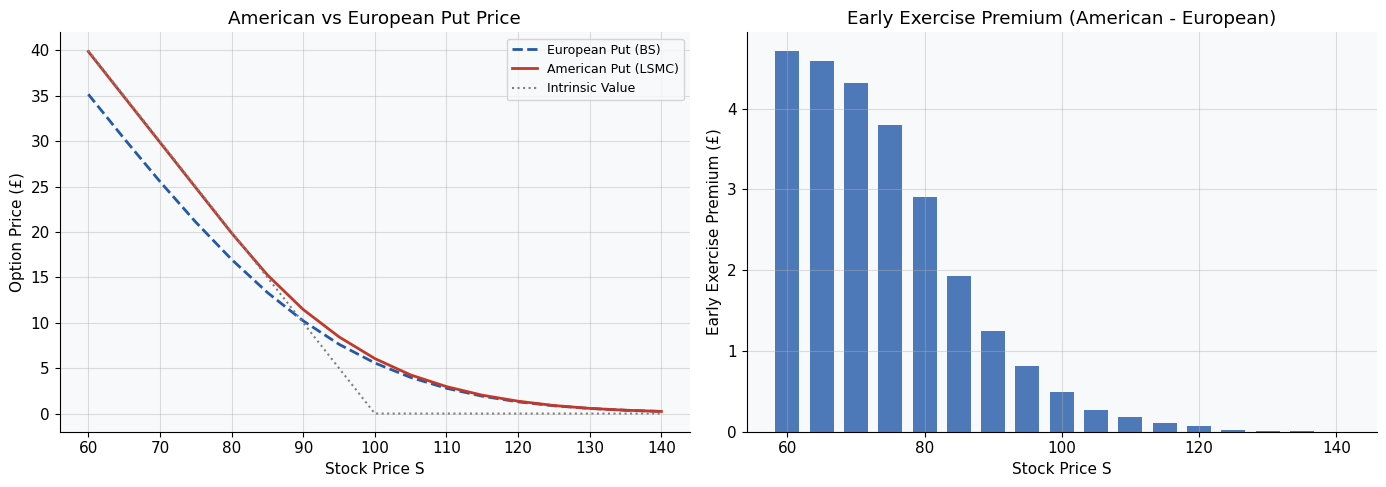

In [21]:
# LONGSTAFF-SCHWARTZ AMERICAN PUT PRICER

def american_put_lsmc(S, K, T, r, sigma, steps=50, n_paths=50_000, seed=42):

    rng = np.random.default_rng(seed)
    dt = T / steps
    discount = np.exp(-r * dt)   #per-step discount factor
    
    # Simulating paths

    paths = np.zeros((steps + 1, n_paths)) #matrix where row t = time step, column i = simulated path.
    paths[0] = S
    for t in range(1, steps + 1):
        Z = rng.standard_normal(n_paths)
        paths[t] = paths[t-1] * np.exp(
            (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
        ) #discrete GBM evolution where Z is normally distributed 
    

    cashflows = np.maximum(K - paths[-1], 0)   # put payoff at maturity T
    
    # backward induction
    for t in range(steps - 1, 0, -1):
        
        cashflows *= discount # discount next periods cash flows back one step
        
        #we only consider in-the-money paths for regression because exercising on the money options makes no sense. If K<S_t, K-S_t<0 so you lose money
    
        S_t = paths[t]
        intrinsic = np.maximum(K - S_t, 0)
        itm = intrinsic > 0   # boolean mask for in-the-money paths
        
        if itm.sum() < 5:     # if too few ITM paths, skip 
            continue
     
        X = np.column_stack([
            np.ones(itm.sum()),
            S_t[itm],
            S_t[itm]**2
        ]) #polynomial basis functions [1, S_t, S_t²]
 
        Y = cashflows[itm]   # continuation value 
        beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None) #simple least square 
        continuation = X @ beta    # fitted continuation values for ITM paths
        
        #exercise if intrinsic > estimated continuation
        exercise = intrinsic[itm] > continuation
        
        # if exercised replace future payoff with immediate payoff, otherwise keep future continuation payoff.
        cashflows[itm] = np.where(exercise, intrinsic[itm], cashflows[itm])
    
    
    cashflows *= discount
    # final price 
    return cashflows.mean()


# COMPARING AMERICAN VS EUROPEAN PUT 

S, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20

eu_put = black_scholes(S, K, T, r, sigma, 'put')
am_put = american_put_lsmc(S, K, T, r, sigma, steps=50, n_paths=100_000)
early_exercise_premium = am_put - eu_put

print(f"European Put (BS closed form): £{eu_put:.4f}")
print(f"American Put (LSMC):           £{am_put:.4f}")
print(f"Early Exercise Premium:        £{early_exercise_premium:.4f}")


# early exercise premium as a function of spot 
spots = np.arange(60, 145, 5)
eu_puts = [black_scholes(s, K, T, r, sigma, 'put') for s in spots]
am_puts = [american_put_lsmc(s, K, T, r, sigma, steps=50, n_paths=30_000) for s in spots]
premiums = np.array(am_puts) - np.array(eu_puts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(spots, eu_puts, '--', color='#2459A8', lw=2, label='European Put (BS)')
ax.plot(spots, am_puts, '-',  color='#C0392B', lw=2, label='American Put (LSMC)')
ax.plot(spots, np.maximum(K - np.array(spots), 0), ':', color='gray', lw=1.5, label='Intrinsic Value')
ax.set_xlabel('Stock Price S')
ax.set_ylabel('Option Price (£)')
ax.set_title('American vs European Put Price')
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(spots, np.maximum(premiums, 0), color='#2459A8', alpha=0.8, width=3.5)
ax.set_xlabel('Stock Price S')
ax.set_ylabel('Early Exercise Premium (£)')
ax.set_title('Early Exercise Premium (American - European)')

plt.tight_layout()
plt.savefig('american_option.png', dpi=150, bbox_inches='tight')
plt.show()


The first graph shows a key result: 

$$
V_{\text{American}}
\ge
V_{\text{European}}
$$
because the American option holder has additional flexibility of early exercise.

The first graph compares European put prices using Black-Scholes vs American put prices using Longstaff-Schwartz and the intrinsic value.

The American put curve lies above the European because of more flexibility. Especially when stock price is low because the option becomes deeply in-the-money and immediate exercise becomes increasingly attractive because market might return by expiry.

The second graph visualizes the early exercise premium:

$$
V_{\text{American}}
-
V_{\text{European}}
$$

This graph shows how much additional value is generated purely from the right to exercise early. The premium is largest for deeply in-the-money puts. So the right to exercise early is much more valuable. 

## 6. Heston Stochastic Volatility Model

As discussed before introducing American Options, we know Black Scholes fails because it assumes constant volatility. This gives rise to volatility smile. So clearly, it cannot produce the correct market dynamics for the real world. The weakness of Black-Scholes is not only that volatility is constant. The deeper issue is that market volatility itself behaves like a random variable. We might have periods of calm followed by turbulence, skews, crashes etc. The Heston model addresses this by allowing variance itself to evolve stochastically.

Instead of modelling only

$$
S_t
$$

we simultaneously model

$$
S_t
\quad\text{and}\quad
V_t
$$

where

$$
V_t = \sigma_t^2
$$

is the instantaneous variance.

Here stock process becomes

$$
dS_t = rS_tdt + \sqrt{V_t}S_tdW_t^S
$$

while variance evolves according to 

$$
dV_t
=
\kappa(\theta-V_t)dt
+
\xi\sqrt{V_t}dW_t^V
$$

The first equation says stock prices still follow a diffusion process but volatility is no longer constant it depends on the current variance level. The second equation means variance behaves like a random process but it is faces reversion towards the mean.


The parameter $ \theta$ acts like a long run equilibrium level. 

If variance becomes too high, i.e., $ V_t > \theta $ then $ \kappa(\theta-V_t)$ becomes negative and pushes variance downward. Conversely, if variance becomes too low $ V_t < \theta$ then the drift becomes positive and pushes variance upward. In the real world volatility tends to revert toward a normal level after periods of market stress or calm. This is exactlyy what the above mechanism captures. 

The parameter $\kappa $ controls how aggressively this reversion occurs. Large values of $\kappa$ imply fast reversion. 


The parameter $ \xi$ is called the volatility of volatility. It determines how violently variance itself fluctuates. Higher values produce more unstable volatility and strong volatility smiles.


The final parameter $\rho$ introduces correlation between stock shocks and volatility shocks. This is new and important! 


The Brownian motions satisfy 

$$
\mathrm{Corr}(dW_t^S,dW_t^V)=\rho
$$

For equity markets we typically observe $\rho < 0$ meaning stock prices fall and volatility rises. This phenomenon is known as the Leverage Effect. It is the main culprit of volatility skews.

If stocks crash, investors look for downside protection. This causes OTM put prices and IVs to increase. BS doesn't help but the Heston model captures this naturally through negative correlation between stock returns and volatility.

Since we don't have a closed form solution we have to simulate it numerically. I use the Euler-Maruyama scheme. Time is divided into small intervals

$$
\Delta t = \frac{T}{\text{steps}}
$$

and the SDEs are approximated recursively.

The variance process becomes

$$
V_{t+\Delta t}
=
V_t
+
\kappa(\theta-V_t)\Delta t
+
\xi\sqrt{V_t\Delta t}Z_V
$$

where

$$
Z_V \sim N(0,1)
$$

The first term represents current variance. The second term represents mean reversion. The third term introduces randomness.

So the stock process becomes

$$
S_{t+\Delta t}
=
S_t
\exp
\left[
\left(r-\frac12V_t\right)\Delta t
+
\sqrt{V_t\Delta t}Z_S
\right]
$$

which is simply the GBM updated step by step with a time varying variance.

The code generates correlated shocks using $Z_S = Z_1$ and $ Z_V=\rho Z_1+\sqrt{1-\rho^2}Z_2$

where $ Z_1,Z_2 \sim N(0,1)$ are independent standard normal variables.

By construction we have $\mathrm{Corr}(Z_S,Z_V)=\rho$ and therefore the desired stock volatility correlation.

My simulation generates thousands of possible stock and variance paths simultaneously.Each path represents one possible future evolution of the market.

##### Extra Comment

An important theoretical requirement is the Feller condition

$$
2\kappa\theta > \xi^2
$$

This condition guarantees that the continuous time variance process remains strictly positive. Intuitively, it states that the mean-reverting force pulling variance back toward its long run level must be sufficiently strong relative to the volatility of volatility term. If the condition is violated, the variance process may become zero. Note the Heston model can still be simulated when the condition fails but positivity is no longer theoretically guaranteed.




Feller condition (2κθ=0.160 > ξ²=0.090): True


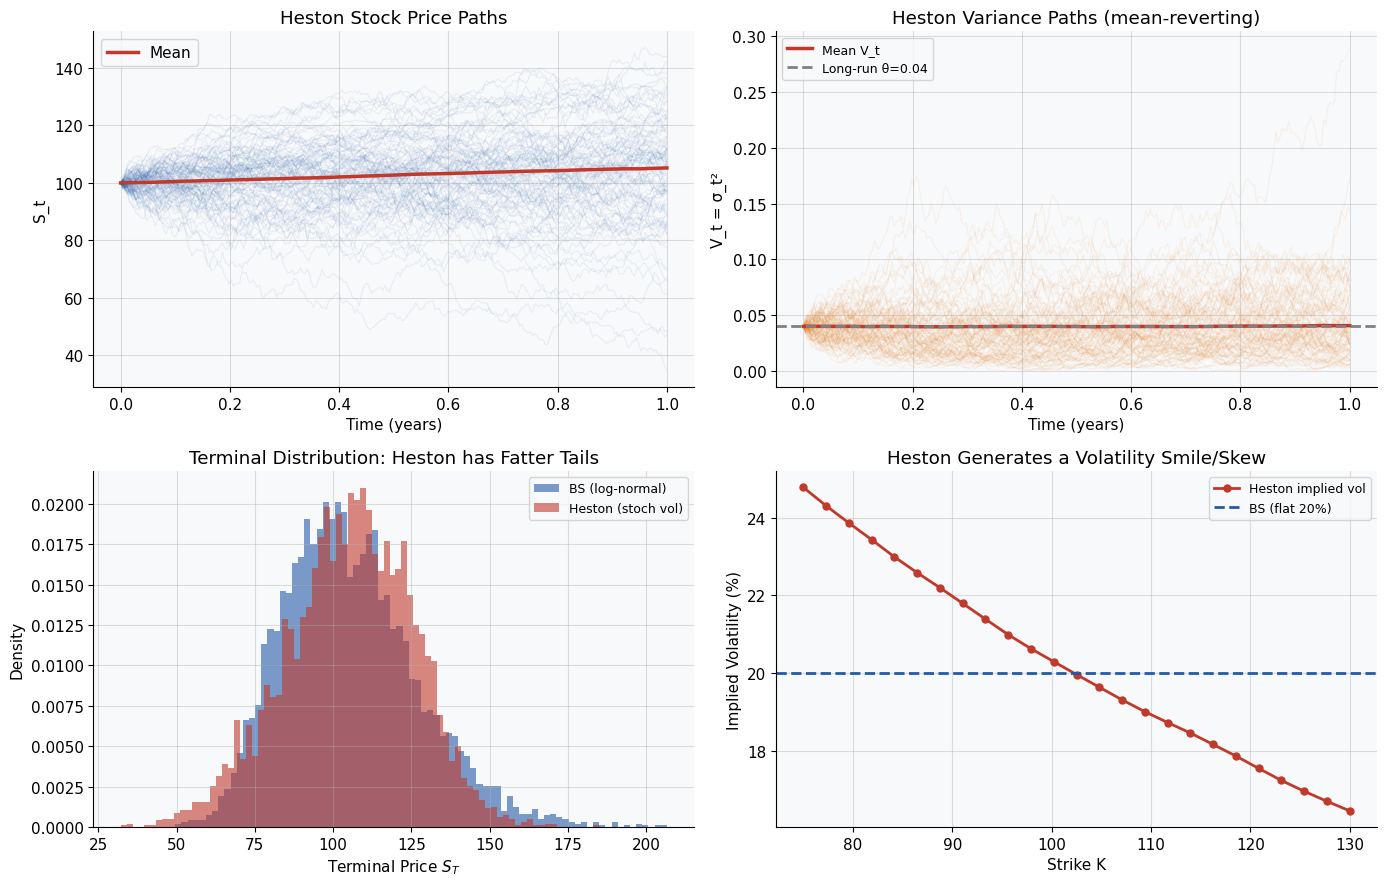


Heston MC Call Price: £10.5730
BS Call Price:        £10.4506
Difference:           £0.1224


In [22]:
# HESTON MODEL SIMULATION

def simulate_heston(S0, V0, T, r, kappa, theta, xi, rho,
                    steps=252, n_paths=10_000, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / steps
    
    S = np.zeros((steps + 1, n_paths));  S[0] = S0 #array of stock price paths 
    V = np.zeros((steps + 1, n_paths));  V[0] = V0 #array of variance paths 
    
    for t in range(1, steps + 1):
        Z1 = rng.standard_normal(n_paths)
        Z2 = rng.standard_normal(n_paths)
        
        #correlated shocks
        Z_S = Z1
        Z_V = rho * Z1 + np.sqrt(1 - rho**2) * Z2
        
        #variance step 
        V[t] = np.maximum(
            V[t-1] + kappa * (theta - V[t-1]) * dt
            + xi * np.sqrt(np.maximum(V[t-1], 0) * dt) * Z_V,
            0
        )
        
        #stock step
        S[t] = S[t-1] * np.exp(
            (r - 0.5 * V[t-1]) * dt + np.sqrt(np.maximum(V[t-1], 0) * dt) * Z_S
        )
    
    return S, V


# starting with standard parameteres 
S0, V0   = 100, 0.04         # S_=100, sigma_0=√0.04=20%
T, r     = 1.0, 0.05         # maturity and interest rate 
kappa    = 2.0               # meanr eversion speed
theta    = 0.04              # long run variance 
xi       = 0.3               # vol of vol
rho      = -0.7              # negative correlation (for skew)

# checking Feller condition 2κθ > ξ² ensures variance is almost surely positive
feller = 2 * kappa * theta > xi**2
print(f"Feller condition (2κθ={2*kappa*theta:.3f} > ξ²={xi**2:.3f}): {feller}")

S_paths, V_paths = simulate_heston(S0, V0, T, r, kappa, theta, xi, rho,
                                    steps=252, n_paths=5000)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
t_grid = np.linspace(0, T, 253)

#stock paths
ax = axes[0, 0]
ax.plot(t_grid, S_paths[:, :100], alpha=0.08, color='#2459A8', lw=0.8)
ax.plot(t_grid, S_paths.mean(axis=1), color='#C0392B', lw=2.5, label='Mean')
ax.set_title('Heston Stock Price Paths')
ax.set_xlabel('Time (years)'); ax.set_ylabel('S_t')
ax.legend()

#variance paths
ax = axes[0, 1]
ax.plot(t_grid, V_paths[:, :100], alpha=0.08, color='#E67E22', lw=0.8)
ax.plot(t_grid, V_paths.mean(axis=1), color='#C0392B', lw=2.5, label='Mean V_t')
ax.axhline(theta, color='gray', ls='--', lw=2, label=f'Long-run θ={theta}')
ax.set_title('Heston Variance Paths (mean-reverting)')
ax.set_xlabel('Time (years)'); ax.set_ylabel('V_t = σ_t²')
ax.legend(fontsize=9)

# comparing terminal distributions Heston vs BS 
ax = axes[1, 0]
S_T_heston = S_paths[-1]
paths_bs = simulate_gbm_paths(100, 1.0, 0.05, 0.20, 252, 5000)
S_T_bs = paths_bs[-1]

ax.hist(S_T_bs,     bins=80, density=True, alpha=0.6, color='#2459A8', label='BS (log-normal)')
ax.hist(S_T_heston, bins=80, density=True, alpha=0.6, color='#C0392B', label='Heston (stoch vol)')
ax.set_xlabel('Terminal Price $S_T$')
ax.set_ylabel('Density')
ax.set_title('Terminal Distribution: Heston has Fatter Tails')
ax.legend(fontsize=9)

#computing iv of Heston MC prices across strikes
ax = axes[1, 1]
strikes_iv = np.linspace(75, 130, 25)
heston_ivs, bs_flat_ivs = [], []
K_ref = 100  # reference point

for k in strikes_iv:
    # Heston price for this strike
    payoffs_h = np.maximum(S_paths[-1] - k, 0)
    heston_price = np.exp(-r * T) * payoffs_h.mean()
    
    #inverting it to get implied vol
    iv = implied_vol(max(heston_price, 1e-8), S0, k, T, r, 'call')
    heston_ivs.append(iv)
    bs_flat_ivs.append(0.20)   # BS always gives flat 20%

ax.plot(strikes_iv, [v*100 if v and not np.isnan(v) else np.nan for v in heston_ivs],
        'o-', color='#C0392B', lw=2, ms=5, label='Heston implied vol')
ax.axhline(20, color='#2459A8', ls='--', lw=2, label='BS (flat 20%)')
ax.set_xlabel('Strike K')
ax.set_ylabel('Implied Volatility (%)')
ax.set_title('Heston Generates a Volatility Smile/Skew')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('heston.png', dpi=150, bbox_inches='tight')
plt.show()

# Price of a call under Heston
K = 100
payoffs_h = np.maximum(S_paths[-1] - K, 0)
heston_call = np.exp(-r * T) * payoffs_h.mean()
bs_call = black_scholes(S0, K, T, r, 0.20, 'call')

print(f"\nHeston MC Call Price: £{heston_call:.4f}")
print(f"BS Call Price:        £{bs_call:.4f}")
print(f"Difference:           £{heston_call - bs_call:.4f}")


The Heston distribution exhibits fatter tails meaning extremely large moves occur often and extremely negative moves occur more often than positive. So the model assigns higher probability to extreme events than Black-Scholes predicts.

Also we can see a natural skew that exists in the Heston model by virtue of its construction ($\rho$ is amazing). BS models all strikes at the same IV but Heston models low strike options with higher IV, hence correctly capturing close to real world market dynamics.

## 7. Using Neural Networks for Option Pricing

Up to this point, all the pricing models we've looked at have relied on explicit mathematical formulas. Black–Scholes gives us a closed-form solution, Monte Carlo methods estimate prices through simulation and models like Heston use stochastic differential equations to describe market behaviour.

Now instead of deriving a formula, we treat option pricing as a function approximation problem. The idea is, if we show a neural network enough examples of option parameters and their corresponding prices, can it learn the relationship between them?

In the Black–Scholes, the option price is determined by the function

$$
C = f(S,K,T,r,\sigma)
$$

where $S$ is the stock price, $K$ is the strike price, $T$ is the time to maturity, $r$ is the risk-free rate, and $\sigma$ is the volatility.

The neural network tries to learn an approximation of this function

$$
\hat C = NN(S,K,T,r,\sigma)
$$

with the goal that

$$
\hat C \approx C_{BS}.
$$

This turns option pricing into a supervised learning problem. The Black–Scholes model provides the correct answers and the neural network learns to imitate those answers from data.

### Generating the Training Data

To train the network, we first need a large collection of examples. The code generates synthetic data by randomly sampling option parameters from the following ranges

$$
70 \le S \le 130
$$

$$
70 \le K \le 130
$$

$$
0.1 \le T \le 3
$$

$$
0 \le r \le 0.1
$$

$$
0.05 \le \sigma \le 0.60
$$

These ranges give us many different scenarios.

For every sampled parameter combination, the exact Black–Scholes price is calculated. Each training example therefore consists of an input vector

$$
X_i=(S_i,K_i,T_i,r_i,\sigma_i)
$$

and a target value

$$
y_i=C_{BS}(X_i).
$$

The final dataset in myy code contains 20,000 of these examples.

### Choosing the feature

A neural network can only learn from the information we provide to it, so choosing useful input features is important.

Instead of feeding the stock price and strike price directly into the model, the code computes

$$
\log\left(\frac{S}{K}\right),
$$

which is known as **log-moneyness**.

This quantity measures how expensive or cheap the stock is relative to the strike price.

When $ S=K,$ we have $\log(S/K)=0$

When $ S>K,$ the option is in-the-money 

When $S<K,$ it is out-of-the-money.

For us relative price levels are more informative than absolute prices. 

The final feature vector becomes

$$
X=
\begin{bmatrix}
\log(S/K)\\
T\\
r\\
\sigma\\
S/K
\end{bmatrix}.
$$

Note that both $\log(S/K)$ and $S/K$ are included. 

### Normalising the output

Rather than predicting the option price directly, the network is trained to predict $\frac{C}{S}$. 

This is done by transforming the target variable as

$$
y=\frac{\text{price}}{S}.
$$

This works because in BS model pricing function scaled linearlyy with size of underlying asset. 

$$
C(\lambda S,\lambda K)
=
\lambda C(S,K).
$$

Normalising through dividing by $S$, we remove unnecessary scale effects and make the learning problem easier for the NN

### Splitting data into Train and Test 

Before training begins, the dataset is divided into two parts. Eighty percent of the data is used for training, while the remaining twenty percent is reserved for testing.

The training set is where the network learns its parameters. The test set is never shown during training and is used to evaluate how well the model performs on new data.

It is important because a model that performs extremely well on the training set may simply have memorised the data rather than learned the underlying relationship. This is known as Overfitting. Testing helps us check this.

### Neural Network Architecture

The model is implemented as a custom PyTorch class derived from the nn.Module

The architecture is

$$
5
\rightarrow
64
\rightarrow
64
\rightarrow
64
\rightarrow
1.
$$

Essentially this means the network receives five input features, passes them through three hidden layers containing 64 neurons each and finally produces a single output value corresponding to the predicted option price.

### Linear Layers

Each hidden layer contains a linear transformation of the form

$$
z = Wx + b,
$$

where $W$ is a matrix of weights and $b$ is a vector of biases.

### SiLU Activation Function

The hidden layers use the SiLU activation function

$$
\text{SiLU}(x)
=
x
\cdot
\frac{1}{1+e^{-x}}.
$$

which smooth and differentiable everywhere.

### Output ReLU Layer

The final layer uses a ReLU activation function to ensure that the predicted price remains non negative

$$
\hat C \ge 0.
$$

Obviouslyyy because we cannot have negative option prices.

### Forward Pass

The forward pass describes how information moves through the network.

Starting from the input features, the data passes through a sequence of linear layers and activation functions until a final prediction is produced

$$
x
\rightarrow
\text{Layer}_1
\rightarrow
\text{SiLU}
\rightarrow
\text{Layer}_2
\rightarrow
\text{SiLU}
\rightarrow
\text{Layer}_3
\rightarrow
\text{SiLU}
\rightarrow
\text{Output}.
$$

At the end of this process, the network outputs its estimate of the option price.

### Optimisation with Adam

Training the network means adjusting its weights so that its predictions become increasingly accurate. This is done here using the Adam optimiser. 

### Loss Function

To measure prediction accuracy, the network uses Mean Squared Error (MSE):

$$
MSE
=
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat y_i)^2.
$$

This measures the average squared difference between the true Black–Scholes prices and the NN's predictions. Smaller is better.

### Backpropagation

After computing the loss, the network must determine how its parameters should change to reduce that error. This is done through backpropagation. PyTorch automatically computes gradients of the loss with respect to every trainable parameter:

$$
\frac{\partial L}{\partial W}.
$$

These gradients indicate the direction in which each weight should move to improve the model's predictions. The optimiser then uses this information to update the parameters.

### Learning Rate Scheduling

The training process also uses a learning rate scheduler.

Every 500 epochs, the learning rate is reduced according to

$$
\eta \leftarrow 0.5\eta.
$$

The intuition is straightforward. Early in training, large updates help the network make rapid progress. Later on, smaller updates allow it to fine-tune its parameters and settle into a more accurate solution.


### The Training Loop

Training consists of repeating the same sequence of operations many times.

For each epoch, the network:

1. Performs a forward pass.
2. Computes the loss.
3. Calculates gradients through backpropagation.
4. Updates its weights.
5. Repeats the process.

Over thousands of iterations, the network gradually improves its approximation of the Black–Scholes pricing function.

### Outcomes

Once training is complete, the network has learned the relationship

$$
C=f(S,K,T,r,\sigma).
$$

During prediction, it no longer evaluates the Black–Scholes formula directly. Instead, the pricing relationship is stored implicitly within the learned weights and biases of the network.

Eventhough we already know BS formula so this might be useless, it was important for me to understand this because I don't have much ML practice. This could be helpful in creating a pipeline for derivatives which are more complex. . 

In [23]:
# NEURAL NETWORK 

print("Generating BS training dataset...")

# Dataset: random combinations of (S, K, T, r, σ) which is mapped to BS price 

rng = np.random.default_rng(0) # random sampling is much better than grid sampling for neural nets
n_samples = 20_000

S_samp     = rng.uniform(70, 130,  n_samples)
K_samp     = rng.uniform(70, 130,  n_samples)
T_samp     = rng.uniform(0.1, 3.0, n_samples)
r_samp     = rng.uniform(0.0, 0.1, n_samples)
sigma_samp = rng.uniform(0.05, 0.60, n_samples)

# compute exact BS prices 
prices = np.array([
    black_scholes(s, k, t, r, sig, 'call')
    for s, k, t, r, sig in zip(S_samp, K_samp, T_samp, r_samp, sigma_samp)
], dtype=np.float32)

#Normalise inputs

log_moneyness = np.log(S_samp / K_samp).astype(np.float32)

X = np.column_stack([
    log_moneyness,                    # log(S/K) —  moneyness
    T_samp.astype(np.float32),
    r_samp.astype(np.float32),
    sigma_samp.astype(np.float32),
    (S_samp / K_samp).astype(np.float32)   # S/K ratio directly too
]).astype(np.float32)

# Normalise price by S (scale-invariance: option value is homogeneous degree 1 in S,K)
y = (prices / S_samp).astype(np.float32).reshape(-1, 1)

# train test split 
split = int(0.8 * n_samples)
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te)


class PricingNN(nn.Module):
    def __init__(self, input_dim=5, hidden=64, depth=3):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, 1), nn.ReLU()]  # ReLU output: prices ≥ 0
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


model = PricingNN(input_dim=5, hidden=64, depth=3)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

#Training
print("Training neural network...")
train_losses, test_losses = [], []

for epoch in range(2000):
    model.train()
    optimizer.zero_grad()
    pred = model(X_tr_t)
    loss = nn.functional.mse_loss(pred, y_tr_t)
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    if epoch % 100 == 0:
        model.eval()
        with torch.no_grad():
            te_loss = nn.functional.mse_loss(model(X_te_t), y_te_t).item()
        train_losses.append(loss.item())
        test_losses.append(te_loss)
        if epoch % 500 == 0:
            print(f"  Epoch {epoch:4d}  Train MSE: {loss.item():.6f}  "
                  f"Test MSE: {te_loss:.6f}")

print("Training complete.")


Generating BS training dataset...
Training neural network...
  Epoch    0  Train MSE: 0.045066  Test MSE: 0.041009
  Epoch  500  Train MSE: 0.000656  Test MSE: 0.000660
  Epoch 1000  Train MSE: 0.000389  Test MSE: 0.000386
  Epoch 1500  Train MSE: 0.000310  Test MSE: 0.000305
Training complete.


Neural Network Performance on Test Set
  Mean Absolute Error:         £1.1980
  Median Absolute Error:       £0.8099
  Mean Relative Error:         27.154%
  Max Absolute Error:          £10.4343
  R² score:                    0.988296


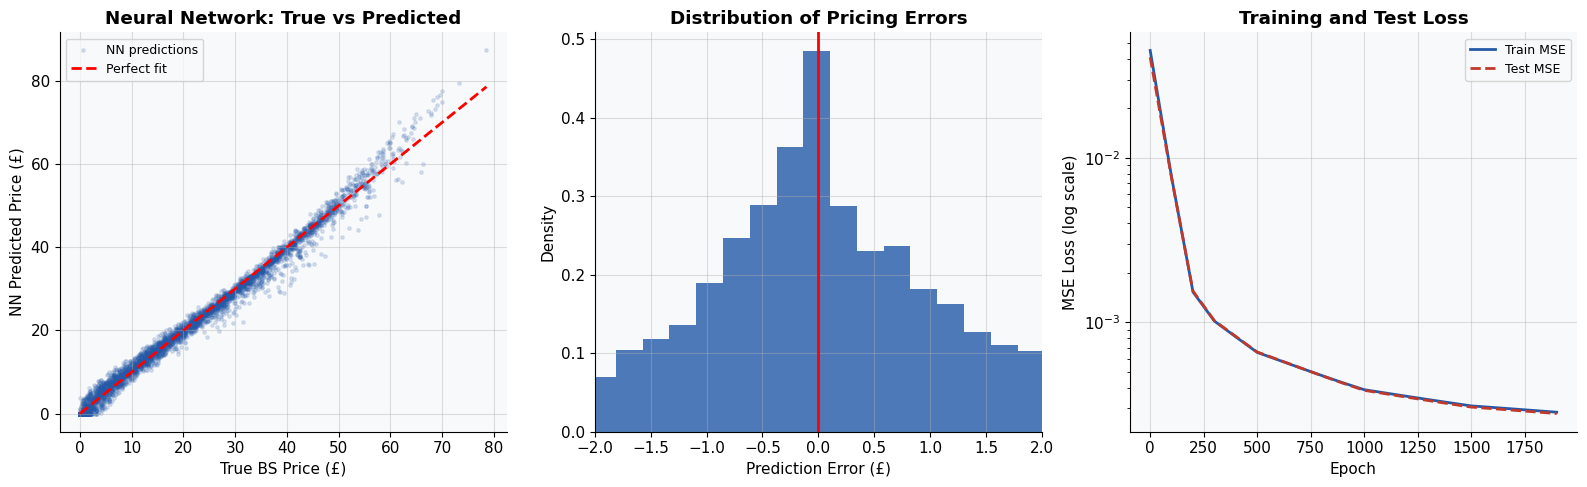

In [24]:
# comparing NN predictions against exact BS on test 

model.eval()
with torch.no_grad():
    y_pred_t = model(X_te_t).numpy()

# Unnormalise: multiply back by S
S_te = S_samp[split:]
y_true_prices = y_te * S_te.reshape(-1, 1)
y_pred_prices = y_pred_t * S_te.reshape(-1, 1)

errors = y_pred_prices - y_true_prices
abs_errors = np.abs(errors)
rel_errors = np.abs(errors / (y_true_prices + 1e-8)) * 100  # avoid div by zero

print("Neural Network Performance on Test Set")
print(f"  Mean Absolute Error:         £{abs_errors.mean():.4f}")
print(f"  Median Absolute Error:       £{np.median(abs_errors):.4f}")
print(f"  Mean Relative Error:         {rel_errors.mean():.3f}%")
print(f"  Max Absolute Error:          £{abs_errors.max():.4f}")
print(f"  R² score:                    {1 - np.var(errors)/np.var(y_true_prices):.6f}")

#Plot: true vs predicted 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
flat = y_true_prices.flatten()
pred_flat = y_pred_prices.flatten()
ax.scatter(flat, pred_flat, alpha=0.15, s=6, color='#2459A8', label='NN predictions')
ax.plot([flat.min(), flat.max()], [flat.min(), flat.max()],
        'r--', lw=2, label='Perfect fit')
ax.set_xlabel('True BS Price (£)')
ax.set_ylabel('NN Predicted Price (£)')
ax.set_title('Neural Network: True vs Predicted', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(errors.flatten(), bins=80, color='#2459A8', alpha=0.8, density=True)
ax.axvline(0, color='red', lw=2)
ax.set_xlabel('Prediction Error (£)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Pricing Errors', fontweight='bold')
ax.set_xlim(-2, 2)

ax = axes[2]
epochs_tracked = np.arange(0, 2000, 100)
ax.semilogy(epochs_tracked, train_losses, lw=2, color='#2459A8', label='Train MSE')
ax.semilogy(epochs_tracked, test_losses,  lw=2, color='#C0392B', label='Test MSE', ls='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (log scale)')
ax.set_title('Training and Test Loss', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('nn_bs.png', dpi=150, bbox_inches='tight')
plt.show()


Let me also try to do the same for Heston Pricing Model

In [25]:

# Learning the Heston Pricing Functional
# Input: (S0, V0, K, T, r, κ, θ, ξ, ρ)  
# Output: Heston MC call price

print("Generating Heston training dataset...")

rng = np.random.default_rng(1)
n_heston = 3_000  

S0_h    = rng.uniform(80,  120,  n_heston)
V0_h    = rng.uniform(0.01, 0.09, n_heston)   # σ₀ between 10% and 30%
K_h     = rng.uniform(80,  120,  n_heston)
T_h     = rng.uniform(0.2,  2.0, n_heston)
r_h     = rng.uniform(0.0,  0.1, n_heston)
kappa_h = rng.uniform(0.5,  5.0, n_heston)
theta_h = rng.uniform(0.01, 0.09, n_heston)
xi_h    = rng.uniform(0.1,  0.6, n_heston)
rho_h   = rng.uniform(-0.9, -0.1, n_heston)  # negative

heston_prices = []
for i in range(n_heston):
    S_p, _ = simulate_heston(S0_h[i], V0_h[i], T_h[i], r_h[i],
                              kappa_h[i], theta_h[i], xi_h[i], rho_h[i],
                              steps=50, n_paths=1000, seed=i)  # fast MC
    payoffs = np.maximum(S_p[-1] - K_h[i], 0)
    price = np.exp(-r_h[i] * T_h[i]) * payoffs.mean()
    heston_prices.append(price)
    if (i+1) % 500 == 0:
        print(f"  {i+1}/{n_heston} done")

heston_prices = np.array(heston_prices, dtype=np.float32)
print("Dataset generated.")

# Building and training Heston network
X_h = np.column_stack([
    np.log(S0_h / K_h).astype(np.float32),   # log-moneyness
    V0_h.astype(np.float32),
    T_h.astype(np.float32),
    r_h.astype(np.float32),
    kappa_h.astype(np.float32),
    theta_h.astype(np.float32),
    xi_h.astype(np.float32),
    rho_h.astype(np.float32),
])
y_h = (heston_prices / S0_h.astype(np.float32)).reshape(-1, 1)

sp = int(0.8 * n_heston)
X_h_tr = torch.tensor(X_h[:sp]);  y_h_tr = torch.tensor(y_h[:sp])
X_h_te = torch.tensor(X_h[sp:]);  y_h_te = torch.tensor(y_h[sp:])

heston_model = PricingNN(input_dim=8, hidden=128, depth=4)
opt_h = optim.Adam(heston_model.parameters(), lr=3e-4, weight_decay=1e-5)
sch_h = optim.lr_scheduler.StepLR(opt_h, step_size=300, gamma=0.6)

print("Training Heston network...")
for epoch in range(1500):
    heston_model.train()
    opt_h.zero_grad()
    loss_h = nn.functional.mse_loss(heston_model(X_h_tr), y_h_tr)
    loss_h.backward()
    opt_h.step(); sch_h.step()
    if epoch % 500 == 0:
        heston_model.eval()
        with torch.no_grad():
            te = nn.functional.mse_loss(heston_model(X_h_te), y_h_te).item()
        print(f"  Epoch {epoch:4d}  Train: {loss_h.item():.5f}  Test: {te:.5f}")

heston_model.eval()
with torch.no_grad():
    y_h_pred = heston_model(X_h_te).numpy()

true_h = y_h[sp:] * S0_h[sp:].reshape(-1, 1)
pred_h = y_h_pred * S0_h[sp:].reshape(-1, 1)
err_h = np.abs(pred_h - true_h)

print(f"\nHeston NN — Mean Absolute Error: £{err_h.mean():.4f}")
print(f"Heston NN — Mean Relative Error: {(err_h/(true_h+1e-8)*100).mean():.2f}%")


Generating Heston training dataset...
  500/3000 done
  1000/3000 done
  1500/3000 done
  2000/3000 done
  2500/3000 done
  3000/3000 done
Dataset generated.
Training Heston network...
  Epoch    0  Train: 0.02437  Test: 0.02359
  Epoch  500  Train: 0.02437  Test: 0.02359
  Epoch 1000  Train: 0.02437  Test: 0.02359

Heston NN — Mean Absolute Error: £13.0872
Heston NN — Mean Relative Error: 99.50%
